In [1]:
import pandas as pd
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

project_id = "dh-global-sales-data-dev"

/home/jupyter/vendor_matching_exp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Data

In [ ]:
"""
select 
b.lead_id as left_lead_id, f.left_name, f.left_name_local, f.left_street, f.left_lat, f.left_lng, f.left_phone_number, array_agg(distinct d.item_name IGNORE NULLS) as left_menu,
c.lead_id as right_lead_id, f.right_name, f.right_name_local, f.right_street, f.right_lat, f.right_lng, f.right_phone_number, array_agg(distinct e.item_name IGNORE NULLS) as right_menu,
a.predicted_label, a.prob,
from `dh-global-sales-data.leadgen_sf_match_vertex_raw.matched_PY_AR` a
left join `dh-global-sales-data.leadgen_sf_match_vertex_raw.candidates_PY_AR` f on a.left_row_id = f.left_row_id and a.right_row_id = f.right_row_id
left join `leadgen_cl.vendor_complete` b on `dh-global-sales-data.achilles.row_id_to_lead_id`(a.left_row_id) = b.lead_id and `dh-global-sales-data.achilles.row_id_to_lead_source`(a.left_row_id) = b.lead_source and (b.country_iso ="AR" or b.global_entity_id = 'PY_AR')
left join `leadgen_cl.vendor_complete` c on `dh-global-sales-data.achilles.row_id_to_lead_id`(a.right_row_id) = c.lead_id and (b.country_iso ="AR" or b.global_entity_id = 'PY_AR')
left join `dh-global-sales-data.markup_menu_match_raw.online_menu_layer_input_PY_AR` d on b.lead_id = d.lead_id and d.lead_provider = 'dataweave' and d.lead_source = 'rappi'
left join `dh-global-sales-data.markup_menu_match_raw.online_menu_layer_input_PY_AR` e on c.sf_vendor_id = e.lead_id and e.lead_provider = 'dwh'
where 
a.prob >= 0.95
and a.predicted_label = 1
and `dh-global-sales-data.achilles.row_id_to_lead_source`(a.left_row_id)='rappi'
group by
b.lead_id,
c.lead_id,
a.predicted_label,
a.prob,
f.left_name, f.left_name_local, f.left_street, f.left_lat, f.left_lng, f.left_phone_number,
f.right_name, f.right_name_local, f.right_street, f.right_lat, f.right_lng, f.right_phone_number
HAVING
 ARRAY_LENGTH(ARRAY_AGG(d.item_name IGNORE NULLS)) > 0
 AND
 ARRAY_LENGTH(ARRAY_AGG(e.item_name IGNORE NULLS)) > 0;
"""

In [ ]:
"""
select 
b.lead_id as left_lead_id, f.left_name, f.left_name_local, f.left_street, f.left_lat, f.left_lng, f.left_phone_number, array_agg(distinct d.item_name IGNORE NULLS) as left_menu,
c.lead_id as right_lead_id, f.right_name, f.right_name_local, f.right_street, f.right_lat, f.right_lng, f.right_phone_number, array_agg(distinct e.item_name IGNORE NULLS) as right_menu,
a.predicted_label, a.prob,
from `dh-global-sales-data.leadgen_sf_match_vertex_raw.matched_PY_AR` a
left join `dh-global-sales-data.leadgen_sf_match_vertex_raw.candidates_PY_AR` f on a.left_row_id = f.left_row_id and a.right_row_id = f.right_row_id
left join `leadgen_cl.vendor_complete` b on `dh-global-sales-data.achilles.row_id_to_lead_id`(a.left_row_id) = b.lead_id and `dh-global-sales-data.achilles.row_id_to_lead_source`(a.left_row_id) = b.lead_source and (b.country_iso ="AR" or b.global_entity_id = 'PY_AR')
left join `leadgen_cl.vendor_complete` c on `dh-global-sales-data.achilles.row_id_to_lead_id`(a.right_row_id) = c.lead_id and (b.country_iso ="AR" or b.global_entity_id = 'PY_AR')
left join `dh-global-sales-data.markup_menu_match_raw.online_menu_layer_input_PY_AR` d on b.lead_id = d.lead_id and d.lead_provider = 'dataweave' and d.lead_source = 'rappi'
left join `dh-global-sales-data.markup_menu_match_raw.online_menu_layer_input_PY_AR` e on c.sf_vendor_id = e.lead_id and e.lead_provider = 'dwh'
where 
a.prob <= 0.05
and a.predicted_label = 0
and `dh-global-sales-data.achilles.row_id_to_lead_source`(a.left_row_id)='rappi'
group by
b.lead_id,
c.lead_id,
a.predicted_label,
a.prob,
f.left_name, f.left_name_local, f.left_street, f.left_lat, f.left_lng, f.left_phone_number,
f.right_name, f.right_name_local, f.right_street, f.right_lat, f.right_lng, f.right_phone_number
HAVING
 ARRAY_LENGTH(ARRAY_AGG(d.item_name IGNORE NULLS)) > 0
 AND
 ARRAY_LENGTH(ARRAY_AGG(e.item_name IGNORE NULLS)) > 0;
"""

In [2]:
query = """
select * from `dh-global-sales-data-dev.leadgen_temp.exp_training_data_match_PY_AR`
"""

df_training_data_match_py_ar = pd.read_gbq(query=query, project_id = project_id, progress_bar_type = 'tqdm')

/var/tmp/ipykernel_4262/2799234831.py:5: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_training_data_match_py_ar = pd.read_gbq(query=query, project_id = project_id, progress_bar_type = 'tqdm')


Downloading: 100%|██████████|


In [ ]:
query = """
select * from `dh-global-sales-data-dev.leadgen_temp.exp_training_data_no_match_PY_AR`
"""

df_training_data_no_match_py_ar = pd.read_gbq(query=query, project_id = project_id, progress_bar_type = 'tqdm')

/var/tmp/ipykernel_4262/1089995511.py:5: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_training_data_no_match_py_ar = pd.read_gbq(query=query, project_id = project_id, progress_bar_type = 'tqdm')


Downloading: 100%|██████████|


In [4]:
df_training_data_match_py_ar.head()

,left_lead_id,left_name,left_name_local,left_street,left_lat,left_lng,left_phone_number,left_menu,right_lead_id,right_name,right_name_local,right_street,right_lat,right_lng,right_phone_number,right_menu,predicted_label,prob
0,77abc3b9-5f13-4e3e-a219-66c8d7edc042,cow sins burgers,cow sins burgers,c 10 1037 tolosa provincia de buenos aires arg...,-34.894500,-57.983600,None,"[cheese burger, sweet onion, grilled onion bur...",HRBS4R,cowsins burgers,cowsins burgers,calle 521 entre 9 y 19 n 1437 tolosa la plata ...,-34.893563,-57.983871,+5492215953769,"[big cow, sweet onion, cowsins burger, bacon c...",1,0.990943
1,93c23f21-8275-4752-88d8-8f2b75e0dcb0,masa madre bkry,masa madre bkry,callao,-32.936484,-60.658664,None,"[medialuna dulce, pancakes, pan de molde, maca...",4OXZ0I,masa madre bakery,masa madre bakery,callao 286,-32.936484,-60.658664,+5493413607023,"[lemón pie, tostado de tu vida, chipa de queso...",1,0.996028
2,1058fbbc-6af5-4f4c-a0d7-4570479eaaa7,don armando microcentro,don armando microcentro,viamonte,-34.600207,-58.380212,None,"[cremonas por 500 grs, pastafrola de membrillo...",HW1P2M,don armando - san nicolas,don armando - san nicolas,viamonte 936,-34.600207,-58.380212,+5491155177562,"[libritos por 500 g, empanadas rotiseras de ca...",1,0.995495
3,709336ba-dfb2-466f-8a52-24c22fd58e88,maracumango tropical,maracumango tropical,sol de mayo,-31.415464,-64.209982,None,"[helado sabores tropicales 1/4kg, helado de lú...",HKR9JQ,maracumango tropical,maracumango tropical,sol de mayo 547,-31.415535,-64.210023,+5493516675071,"[helado sabores tradicionales 1/4 kg, helado s...",1,0.998465
4,13400282-c6c0-4305-8db2-b9a02b9bf2b4,rollstar - castelar,rollstar - castelar,sta rosa,-34.640777,-58.656034,None,"[sashimi lango, selección trend 30 piezas, wo...",45U7R0,rollstar castelar,rollstar castelar,santa rosa 1727,-34.640683,-58.655738,+5491161628227,"[vegetarian roll, poke vegano, sashimi blanco,...",1,0.990353


In [5]:
len(df_training_data_match_py_ar)

10660

In [59]:
df_training_data_no_match_py_ar.head()

,left_lead_id,left_name,left_name_local,left_street,left_lat,left_lng,left_phone_number,left_menu,right_lead_id,right_name,right_name_local,right_street,right_lat,right_lng,right_phone_number,right_menu,predicted_label,prob
0,48d72e53-fa6d-4249-8bce-3a71b2096574,solo empanadas caballito,solo empanadas caballito,av la plata 336 ciudad autonoma de buenos aire...,-34.618700,-58.428100,None,"[pizza calabresa, docena muzzarella grande, a...",4OVL4A,la farola de caballito,la farola de caballito,avenida independencia 4399 entre muniz y la plata,-34.621893,-58.427613,+5491149831437,"[revuelto de gramajo, tallarines para dos pers...",0,0.001480
1,838ba43e-529d-4c92-8624-ed0b85641d05,leroma nva cba - turbo,leroma nva cba - turbo,av hipolito yrigoyen,-31.421900,-64.187883,None,"[paleta snicker, mini paletas premium x 4, hel...",HR8P5S,ramirez bar,ramirez bar,rondeau 58 x5000 cordoba argentina,-31.422280,-64.185757,+5493516067001,"[xl, lomo chedar, lomo alito, bebida sprite re...",0,0.003312
2,cb73ad98-a508-448d-99a1-ad9f87885d7e,1516 cerveceria - palermo,1516 cerveceria - palermo,jose a cabrera,-34.588422,-58.434204,None,"[hongos a la plancha, papas bravas, quesadilla...",HWQ8UQ,arepera miss venezuela - palermo,arepera miss venezuela - palermo,humboldt 2341,-34.579873,-58.429528,+5491161482687,"[miss venezuela, miss perico acompa�ado, cochi...",0,0.001996
3,2686bf5c-2a92-4ce0-82ad-41c85fa4aa77,gout gluten free - alto rosario,gout gluten free - alto rosario,junin,-32.926737,-60.669304,None,"[macarons frambuesa, medialuna de manteca, cua...",HKPGEJ,el noble alto rosario,el noble alto rosario,junin 501,-32.927701,-60.670054,+5490341547637,"[empanadas a elección, docena promocional, spr...",0,0.005842
4,827ac52e-d8c4-429a-b629-8f6f7dd5612c,el nuevo hornito caballito,el nuevo hornito caballito,av tte gral donato alvarez,-34.618793,-58.457098,None,"[pizza con rúcula, pizza con port salut, papas...",HKLKNY,ayulem caballito,ayulem caballito,av pedro goyena 1383,-34.627278,-58.446725,+5491128604200,"[medialuna vegana x unidad, baguetin jamón coc...",0,0.002105


In [60]:
len(df_training_data_no_match_py_ar)

191047

In [61]:
sample_match_py_ar = df_training_data_match_py_ar.sample(n=5000, random_state=1)

In [62]:
sample_no_match_py_ar = df_training_data_no_match_py_ar.sample(n=5000, random_state=1)

In [63]:
training_data_py_ar = pd.concat([sample_match_py_ar,sample_no_match_py_ar], ignore_index=True)

In [64]:
training_data_py_ar = training_data_py_ar.sample(frac=1).reset_index(drop=True)

In [65]:
training_data_py_ar[(training_data_py_ar["left_phone_number"].isna()==False)&(training_data_py_ar["right_phone_number"].isna()==False)]

,left_lead_id,left_name,left_name_local,left_street,left_lat,left_lng,left_phone_number,left_menu,right_lead_id,right_name,right_name_local,right_street,right_lat,right_lng,right_phone_number,right_menu,predicted_label,prob


In [66]:
training_data_py_ar = training_data_py_ar.drop(columns=["left_phone_number", "right_phone_number"])

In [67]:
def concatenate_menu(text_array):
    return " ".join(text_array)

training_data_py_ar["left_menu"] = training_data_py_ar.apply(lambda x: concatenate_menu(x.left_menu), axis=1)
training_data_py_ar["right_menu"] = training_data_py_ar.apply(lambda x: concatenate_menu(x.right_menu), axis=1)

In [68]:
spanish_stopwords_menu = [
    "a", "al", "algo", "alguna", "algunas", "alguno", "algunos", "ante", "antes", "bajo", "cual", "cuales", 
    "cualquier", "cuando", "de", "debe", "del", "demás", "demasiado", "desde", "donde", "dos", "durante", "e", 
    "el", "ella", "ellas", "ellos", "en", "encima", "entonces", "entre", "esta", "estas", "este", "esto", "estos", 
    "la", "las", "lo", "los", "me", "mi", "mis", "muchos", "muy", "nada", "ni", "ningún", "ninguna", "ninguno", "no", 
    "nos", "nosotros", "nuestra", "nuestro", "os", "para", "pero", "por", "porque", "que", "quien", "quienes", "se", 
    "si", "sí", "sólo", "son", "su", "sus", "suya", "suyo", "tal", "tales", "también", "te", "tendrá", "tengo", "tiempo", 
    "toda", "todas", "todo", "todos", "tras", "un", "una", "unas", "uno", "unos", "usted", "y", "ya", "yo", "kg", "pz", "pieza"
]

def extract_top_keywords(text, top_n=50):
    """
    Given a text string, clean it and then fit a TF-IDF vectorizer on it (as a single document)
    to extract the top_n keywords. Returns the keywords as a single space‐joined string.
    If the cleaned text is empty, returns a single space " ".
    """
    # if not isinstance(text, str) or not text.strip():
    #     return " "
    
    # # Clean the text.
    # cleaned_text = clean_text(text)
    # if not cleaned_text.strip():
    #     return " "
    cleaned_text = text
    
    # Pass the stopwords to the vectorizer as well.
    vectorizer = TfidfVectorizer(stop_words=spanish_stopwords_menu)
    tfidf_matrix = vectorizer.fit_transform([cleaned_text])
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = tfidf_matrix.toarray()[0]
    
    # Get indices of the top_n scores in descending order.
    sorted_indices = np.argsort(tfidf_scores)[::-1]
    top_keywords = [feature_names[i] for i in sorted_indices[:top_n]]
    return " ".join(top_keywords)

In [69]:
training_data_py_ar["left_keywords"] = training_data_py_ar.apply(lambda x: extract_top_keywords(x.left_menu), axis=1)
training_data_py_ar["right_keywords"] = training_data_py_ar.apply(lambda x: extract_top_keywords(x.right_menu), axis=1)

In [70]:
training_data_py_ar = training_data_py_ar.rename(columns={"left_street":"left_address", "right_street":"right_address"})

In [71]:
training_data_py_ar.head()

,left_lead_id,left_name,left_name_local,left_address,left_lat,left_lng,left_menu,right_lead_id,right_name,right_name_local,right_address,right_lat,right_lng,right_menu,predicted_label,prob,left_keywords,right_keywords
0,164d1599-a03d-4c4b-b696-576c22b7e8d3,morita parana 11,morita parana 11,av almafuerte,-31.749102,-60.506202,pepsi black 500 ml coca cola 500 ml coca cola ...,4CWFSD,morita parana 11 almafuerte,morita parana 11 almafuerte,avenida almafuerte 901,-31.749102,-60.506202,cerveza stella artois lata 473ml pizza calabre...,1,0.998369,pizza piedra pepsi cola coca sin lata sprite m...,pizza porciones jamón individual empanadas gra...
1,8c45727e-f399-4f0e-afd5-1272688db307,mccafe - smg,mccafe - smg,av pres juan domingo peron,-34.547497,-58.705346,poundcake devils cake. café americano croissan...,45D8MY,mccafe smg,mccafe smg,avenida presidente juan domingo peron 989,-34.547393,-58.705516,25off 6 facturas barrita de cereal girasol y a...,1,0.995966,café con latte grande americano tostado espres...,café con queso tostado americano espresso gran...
2,77d64fc9-d752-4e50-93ee-1bbaa811ba8c,sushipop - rosario,sushipop - rosario,san luis,-32.944658,-60.662688,geishas roll new york roll paris roll persia c...,451QJW,sushi pop - rosario ii,sushi pop - rosario ii,san luis 2830,-32.944701,-60.662540,aros de cebolla king combo king de pollo franc...,1,0.973731,roll salmon poke tokyo veggie kani full 40 lan...,combo roll off doble papas pollo xl stacker ki...
3,d4fd4aab-b7f6-453e-a002-0b983247c4c4,lo de jacinto - mendoza,lo de jacinto - mendoza,mariano moreno 239 m5500 mendoza argentina,-32.902100,-68.855000,tarta de brócoli delicia de frutos del bosque ...,HWMFYH,lo de jacinto - mendoza,lo de jacinto - mendoza,mariano moreno 239,-32.902054,-68.855003,queso azul pollo champignones verduras y calab...,1,0.998716,empanada and pizza queso tarta empanadas pizze...,gaseosa 5l 500cc queso pollo cerveza coca 473c...
4,2a27b7cf-cdf3-4abf-876b-e56d25f02a38,club del poke - martinez i,club del poke - martinez i,av sir alexander fleming,-34.505389,-58.515886,arrolladitos primavera x4 jugo pera pura frutt...,4FIVHJ,pastas luisito martinez restaurant,pastas luisito martinez restaurant,parana 3189,-34.505857,-58.515571,"lasagña de ricota, jamón, pollo y acelga empan...",0,0.006938,salad poke sushi crispy pollo promo tu veggie ...,fideos acelga ricota con jamón ravioles queso ...


In [72]:
import math

def compute_haversine(lat1, lon1, lat2, lon2) -> float:
    """
    Returns haversine distance in *km*
    """
    # Convert coordinates from degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    )
    c = 2 * math.asin(math.sqrt(a))

    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

In [73]:
training_data_py_ar["haversine"] = training_data_py_ar.apply(lambda x: compute_haversine(x.left_lat, x.left_lng, x.right_lat, x.right_lng), axis=1)

In [22]:
training_data_py_ar.to_gbq("dh-global-sales-data-dev.leadgen_temp.exp_training_data_PY_AR")

/var/tmp/ipykernel_4262/904230199.py:1: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  training_data_py_ar.to_gbq("dh-global-sales-data-dev.leadgen_temp.exp_training_data_PY_AR")
100%|██████████| 1/1 [00:00<00:00, 10485.76it/s]


## 1. Model 1: bi-encoder with final classification layer (abs diff + haversine)

### 1.1 Architecture and model training

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import pandas as pd

# Define the dual-tower model
class DualTowerBiEncoder(nn.Module):
    def __init__(self, model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", reduced_dim=256, tfidf_dim=100):
        super(DualTowerBiEncoder, self).__init__()
        self.semantic_encoder = SentenceTransformer(model_name)
        self.transformer = self.semantic_encoder._first_module().auto_model
        self.tokenizer = self.semantic_encoder.tokenizer

        # Unfreeze transformer parameters for fine-tuning
        for param in self.transformer.parameters():
            param.requires_grad = True

        hidden_size = self.transformer.config.hidden_size

        self.semantic_projection = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        self.lexical_projection = nn.Sequential(
            nn.Linear(tfidf_dim, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        self.final_projection = nn.Sequential(
            nn.Linear(2 * reduced_dim, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        # Classification head (input includes haversine distance)
        self.classifier = nn.Sequential(
            nn.Linear(reduced_dim + 1, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def encode_semantic(self, name_and_keywords):
        inputs = self.tokenizer(name_and_keywords, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {key: value.to(next(self.semantic_projection.parameters()).device) for key, value in inputs.items()}
        outputs = self.transformer(**inputs)
        text_embedding = outputs.last_hidden_state[:, 0, :]
        return self.semantic_projection(text_embedding)

    def encode_lexical(self, tfidf_vector):
        return self.lexical_projection(tfidf_vector)

    def forward(self, left_text, right_text, left_tfidf, right_tfidf, haversine_dists):
        left_semantic_embed = self.encode_semantic(left_text)
        right_semantic_embed = self.encode_semantic(right_text)

        left_lexical_embed = self.encode_lexical(left_tfidf)
        right_lexical_embed = self.encode_lexical(right_tfidf)

        left_final_embed = self.final_projection(torch.cat((left_semantic_embed, left_lexical_embed), dim=1))
        right_final_embed = self.final_projection(torch.cat((right_semantic_embed, right_lexical_embed), dim=1))

        # Normalize embeddings
        left_final_embed = F.normalize(left_final_embed, p=2, dim=1)
        right_final_embed = F.normalize(right_final_embed, p=2, dim=1)

        # Classification prediction
        abs_diff = torch.abs(left_final_embed - right_final_embed)
        combined = torch.cat((abs_diff, haversine_dists.unsqueeze(1)), dim=1)
        match_prob = self.classifier(combined)

        return left_final_embed, right_final_embed, match_prob

# Dataset class
class VendorMatchingDataset(Dataset):
    def __init__(self, left_names, right_names, left_addresses, right_addresses, left_keywords, right_keywords, haversine_distances, labels):
        self.left_names = left_names
        self.right_names = right_names
        self.left_keywords = left_keywords
        self.right_keywords = right_keywords
        self.left_addresses = left_addresses
        self.right_addresses = right_addresses
        self.haversine_distances = haversine_distances
        self.labels = labels

        self.left_lexical_inputs = [f"{n} {a}" for n, a in zip(left_names, left_addresses)]
        self.right_lexical_inputs = [f"{n} {a}" for n, a in zip(right_names, right_addresses)]
        self.left_semantic_inputs = [f"{n} {' '.join(k)}" for n, k in zip(left_names, left_keywords)]
        self.right_semantic_inputs = [f"{n} {' '.join(k)}" for n, k in zip(right_names, right_keywords)]

        vectorizer = TfidfVectorizer(max_features=100)
        vectorizer.fit(self.left_lexical_inputs + self.right_lexical_inputs)
        self.vectorizer = vectorizer

        self.left_tfidf_vectors = [self.vectorizer.transform([txt]).toarray()[0] for txt in self.left_lexical_inputs]
        self.right_tfidf_vectors = [self.vectorizer.transform([txt]).toarray()[0] for txt in self.right_lexical_inputs]
        self.tfidf_dim = self.left_tfidf_vectors[0].shape[0]

    def __getitem__(self, idx):
        return (
            self.left_semantic_inputs[idx],
            self.right_semantic_inputs[idx],
            torch.tensor(self.left_tfidf_vectors[idx], dtype=torch.float32),
            torch.tensor(self.right_tfidf_vectors[idx], dtype=torch.float32),
            torch.tensor(np.log1p(self.haversine_distances[idx]) / np.log1p(100), dtype=torch.float32),
            self.labels[idx]
        )

    def __len__(self):
        return len(self.labels)

# Training function

import time
import gc

def train_with_split(model, dataset, train_ratio=0.8, epochs=10, batch_size=32, lr=1e-5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    total_size = len(dataset)
    train_size = int(train_ratio * total_size)
    test_size = total_size - train_size
    indices = list(range(total_size))
    np.random.shuffle(indices)

    train_indices = indices[:train_size]
    test_indices = indices[train_size:]

    pd.Series(train_indices).to_csv("train_indices.csv", index=False)
    pd.Series(test_indices).to_csv("test_indices.csv", index=False)

    train_set = torch.utils.data.Subset(dataset, train_indices)
    test_set = torch.utils.data.Subset(dataset, test_indices)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, num_workers=2, pin_memory=True)

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    loss_fn = nn.BCELoss()

    print(f"Training on: {device}")
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        val_loss = 0
        model.train()
        total_loss = 0

        for batch in train_loader:
            left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists, labels = batch
            left_tfidf = left_tfidf.to(device)
            right_tfidf = right_tfidf.to(device)
            haversine_dists = haversine_dists.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            _, _, match_probs = model(left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists)
            loss = loss_fn(match_probs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        model.eval()
        with torch.no_grad():
            for batch in test_loader:
                left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists, labels = batch
                left_tfidf = left_tfidf.to(device)
                right_tfidf = right_tfidf.to(device)
                haversine_dists = haversine_dists.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                _, _, match_probs = model(left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists)
                val_loss += loss_fn(match_probs, labels).item()

        avg_val_loss = val_loss / len(test_loader)
        preds = match_probs.cpu().numpy()
        true = labels.cpu().numpy()
        binary_preds = (preds >= 0.5).astype(int)

        f1 = f1_score(true, binary_preds)
        precision = precision_score(true, binary_preds)
        recall = recall_score(true, binary_preds)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f} - Val Loss: {avg_val_loss:.4f} - F1: {f1:.4f} - Precision: {precision:.4f} - Recall: {recall:.4f}")

    torch.save(model.state_dict(), "trained_model.pt")

    def save_predictions(loader, subset_name):
        model.eval()
        predictions = []
        with torch.no_grad():
            for batch in loader:
                left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists, labels = batch
                left_tfidf = left_tfidf.to(device)
                right_tfidf = right_tfidf.to(device)
                haversine_dists = haversine_dists.to(device)
                labels = labels.float().to(device)
                _, _, match_probs = model(left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists)
                for l, p in zip(labels.cpu().numpy(), match_probs.cpu().numpy()):
                    predictions.append((float(l), float(p)))
        df = pd.DataFrame(predictions, columns=["label", "predicted_probability"])
        df.to_csv(f"{subset_name}_predictions.csv", index=False)

    save_predictions(train_loader, "train")
    save_predictions(test_loader, "test")

    end_time = time.time()
    print(f"Total training time: {(end_time - start_time)/60:.2f} minutes")
    gc.collect()
    torch.cuda.empty_cache()

    return model

In [30]:
#training_dataset = training_data_py_ar[0:100]
training_dataset = training_data_py_ar

In [33]:
# Prepare inputs for dataset
left_names = training_dataset["left_name"].tolist()
right_names = training_dataset["right_name"].tolist()
left_addresses = training_dataset["left_address"].tolist()
right_addresses = training_dataset["right_address"].tolist()
left_keywords = training_dataset["left_keywords"].tolist()
right_keywords = training_dataset["right_keywords"].tolist()
haversines = training_dataset["haversine"].tolist()
labels = training_dataset["predicted_label"].tolist()

# Create dataset
dataset = VendorMatchingDataset(
    left_names, right_names,
    left_addresses, right_addresses,
    left_keywords, right_keywords,
    haversines,
    labels
)

In [94]:
# Initialize model and loss
#model = DualTowerBiEncoder(tfidf_dim=dataset.tfidf_dim)
model = DualTowerBiEncoder()

In [95]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Using device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Using device: Tesla T4


In [96]:
#import time
#start = time.time()
#train_with_split(model, dataset, epochs=1, batch_size=4)
#print(f"One epoch took: {(time.time() - start) / 60:.2f} minutes")

In [99]:
trained_model = train_with_split(model, dataset)

Training on: cuda


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 1/10 - Train Loss: 0.6638 - Val Loss: 0.6531 - F1: 0.7368 - Precision: 0.5833 - Recall: 1.0000


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 2/10 - Train Loss: 0.6458 - Val Loss: 0.6346 - F1: 0.9333 - Precision: 0.8750 - Recall: 1.0000


...

Epoch 9/10 - Train Loss: 0.4939 - Val Loss: 0.5000 - F1: 0.9231 - Precision: 1.0000 - Recall: 0.8571


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 10/10 - Train Loss: 0.4759 - Val Loss: 0.4916 - F1: 0.9231 - Precision: 1.0000 - Recall: 0.8571


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/var/tmp/ipykernel_15705/3417580351.py:214: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions.append((float(l), float(p)))
huggingface/tokenizers: The current process 

Total training time: 21.40 minutes


In [94]:
def extract_vendor_embeddings(model, dataset, output_left="left_vendor_embeddings.csv", output_right="right_vendor_embeddings.csv"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    left_embeddings = []
    right_embeddings = []

    with torch.no_grad():
        for i in range(len(dataset)):
            left_text, right_text, left_tfidf, right_tfidf, _, _ = dataset[i]

            # Process left (semantic + lexical)
            left_tfidf_tensor = left_tfidf.unsqueeze(0).to(device)
            left_text_batch = [left_text]
            left_semantic = model.encode_semantic(left_text_batch)
            left_lexical = model.encode_lexical(left_tfidf_tensor)
            left_combined = torch.cat((left_semantic, left_lexical), dim=1)
            left_embed = model.final_projection(left_combined)
            left_embed = F.normalize(left_embed, p=2, dim=1)
            left_embeddings.append(left_embed.squeeze(0).cpu().numpy())

            # Process right (semantic + lexical)
            right_tfidf_tensor = right_tfidf.unsqueeze(0).to(device)
            right_text_batch = [right_text]
            right_semantic = model.encode_semantic(right_text_batch)
            right_lexical = model.encode_lexical(right_tfidf_tensor)
            right_combined = torch.cat((right_semantic, right_lexical), dim=1)
            right_embed = model.final_projection(right_combined)
            right_embed = F.normalize(right_embed, p=2, dim=1)
            right_embeddings.append(right_embed.squeeze(0).cpu().numpy())

    # Save embeddings
    pd.DataFrame(left_embeddings).to_csv(output_left, index=False)
    pd.DataFrame(right_embeddings).to_csv(output_right, index=False)
    print(f"Saved {len(left_embeddings)} left and right vendor embeddings to {output_left} and {output_right}")

In [151]:
extract_vendor_embeddings(trained_model, dataset)

Saved 10000 left and right vendor semantic embeddings to left_vendor_embeddings.csv and right_vendor_embeddings.csv


### 1.2 Evaluation

#### Classification metrics

In [89]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

def evaluate_predictions_from_csv(csv_path, threshold=0.5):
    """
    Evaluates model predictions saved in a CSV file.

    Parameters:
    - csv_path (str): path to the CSV file with columns ['label', 'predicted_probability']
    - threshold (float): threshold to convert probabilities to binary predictions

    Returns:
    - dict: evaluation metrics
    """
    df = pd.read_csv(csv_path)

    true_labels = df["label"]
    predicted_probs = df["predicted_probability"]
    predicted_labels = (predicted_probs >= threshold).astype(int)

    precision = precision_score(true_labels, predicted_labels)
    recall = recall_score(true_labels, predicted_labels)
    f1 = f1_score(true_labels, predicted_labels)
    roc_auc = roc_auc_score(true_labels, predicted_probs)

    print(f"📊 Evaluation from: {csv_path}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  ROC AUC:   {roc_auc:.4f}")

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

In [4]:
train_predictions_path = 'only_abs_classification_layer/train_predictions.csv'
test_predictions_path = 'only_abs_classification_layer/test_predictions.csv'

In [3]:
evaluate_predictions_from_csv(train_predictions_path)

📊 Evaluation from: only_abs_classification_layer/train_predictions.csv
  Precision: 0.9463
  Recall:    0.9260
  F1 Score:  0.9361
  ROC AUC:   0.9796


{'precision': 0.9463464486458866,
 'recall': 0.926,
 'f1': 0.9360626737427344,
 'roc_auc': np.float64(0.9796019687499999)}

In [5]:
evaluate_predictions_from_csv(test_predictions_path)

📊 Evaluation from: only_abs_classification_layer/test_predictions.csv
  Precision: 0.9089
  Recall:    0.8880
  F1 Score:  0.8983
  ROC AUC:   0.9511


{'precision': 0.9089048106448311,
 'recall': 0.888,
 'f1': 0.8983308042488619,
 'roc_auc': np.float64(0.951124)}

#### Embedding evaluation

In [152]:
left_keywords = training_data_py_ar["left_keywords"].tolist()
right_keywords = training_data_py_ar["right_keywords"].tolist()
keywords = left_keywords + right_keywords

In [153]:
from sklearn.cluster import KMeans
from collections import defaultdict

model_keywords = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
keyword_embeddings = model_keywords.encode(keywords)

# 3. Cluster embeddings (adjust n_clusters as needed)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(keyword_embeddings)

# 4. Group keywords by cluster
clusters = defaultdict(list)
for kw, label in zip(keywords, cluster_labels):
    clusters[label].append(kw)

In [154]:
# Qualitative analysis of clusters for labeling
# 0 -> sweets, cafes
# 1 -> sushi
# 2 -> argentina
# 3 -> pizza, italian
# 4 -> sandwich, burger
clusters[0]

['ml medialuna con dulce pastelito pastelera 355 churro leche premium pan muffins medialunas rellena cortado 177 chocolate pastelitos rellenos roquefort salada rosa muffin persianita relleno rellenas vigilante varilla x6 x10u lágrima media mignon membrillo mini napolitano multigranos infusión flautita donuts dona lagrima infusion grasa gourmet jesuita crema criollitos criollo croissant',
 'café con grande latte americano espresso tostado poundcake queso iced maicena cappuccino alfajor medialuna grand banana vainilla facturas donut manzana lágrima lomo mcqueso cake barrita brunch chocolate cafés té tostados twinings mcquesos medialunas rojos salado sándwich submarino frutos girasol gratis grasa indian manteca machiatto lomito pan pollo nuez naranja mocca',
 'helado palito frutilla bombón sin chocolate pote pizza 20 frutal vainilla yogurt vegano tacc tentacion cremoso postre grido congelada azucar crema familiar tentación torta mozzarella suizo split naranja shot unidades almendrado cass

Adjusted Rand Index (ARI): 0.0621
Normalized Mutual Info (NMI): 0.1053


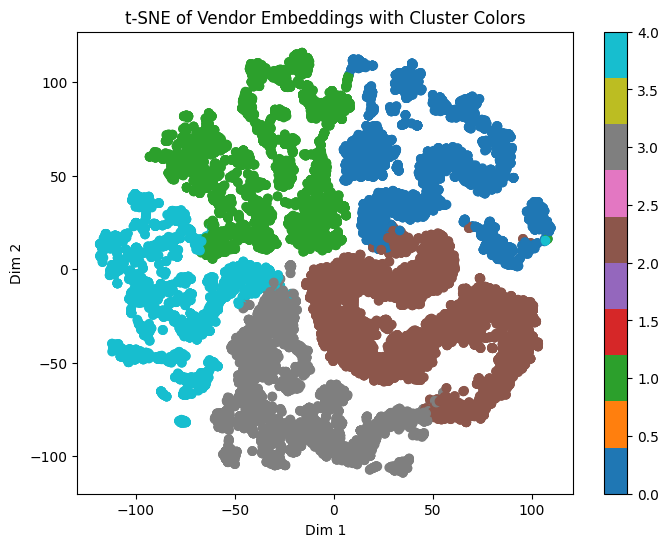

In [157]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load embeddings
left_embeddings_df = pd.read_csv("only_abs_classification_layer/left_vendor_embeddings.csv")
right_embeddings_df = pd.read_csv("only_abs_classification_layer/right_vendor_embeddings.csv")
embeddings_df = pd.concat([left_embeddings_df,right_embeddings_df])
embeddings = embeddings_df.values

# Load labels based on keywords grouping above
true_labels = cluster_labels  

# Run embedding clustering
n_clusters = len(set(true_labels))
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_emb = kmeans.fit_predict(embeddings)

# Evaluate clustering vs keywords grouping
ari = adjusted_rand_score(true_labels, cluster_labels_emb)
nmi = normalized_mutual_info_score(true_labels, cluster_labels_emb)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi:.4f}")

# 4. Visualize
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels_emb, cmap='tab10')
plt.title("t-SNE of Vendor Embeddings with Cluster Colors")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(scatter)
plt.show()

In [159]:
from sklearn.metrics import silhouette_score

score = silhouette_score(embeddings, cluster_labels_emb)

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.5594


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sims = cosine_similarity(embeddings)
vendor_idx = 0  # change this
similar_idxs = np.argsort(-sims[vendor_idx])[1:6]  # skip self

print(f"Top 5 neighbors for vendor {vendor_idx}: {similar_idxs}")

In [136]:
left_cluster_labels = cluster_labels[0:10000].tolist()
right_cluster_labels = cluster_labels[10000:20000].tolist()

In [139]:
training_data_py_ar["left_embedding_cluster_label"]=left_cluster_labels
training_data_py_ar["right_embedding_cluster_label"]=right_cluster_labels

In [147]:
# 1 -> burger, sandwich
# 2 -> pizza, burger, sandwich
# 3 -> pizza, milanesa, empanadas
training_data_py_ar[training_data_py_ar["left_embedding_cluster_label"]==4][["left_name","left_address","left_keywords","left_embedding_cluster_label"]][0:50]

,left_name,left_keywords,left_embedding_cluster_label
1,fabrica de pizzas caballito,empanada pizza grande con mozzarella pepsi ml ...,4
2,orale juanito - ramos mejia,taco juanito hamburguesa ensalada orale pollo ...,4
3,pizza pizuela,pizza queso ml jamón 500 tarta empanada and mo...,4
14,fabrica de pizzas escobar,empanada pizza grande con mozzarella jamón pro...,4
17,pranzo empanadas belgrano,ml empanada naranja 473 sin aquarius pomelo 25...,4
19,pizza steve - rosario sarmiento 976,vegana cebolla con dip pizza pepsi queso marga...,4
20,abadia deleuze - palermo,ml 473 abadía deleuze fritas con mila tiramisú...,4
24,tostado cafe club - obelisco - turbo,grande eleccion tostado sin con cafe choco 354...,4
27,fabrica de pizzas palermo,empanada pizza grande con ml mozzarella pepsi ...,4
28,casa saenz - belgrano,torta sándwich papas galleta fritas chocolate ...,4


## 2. Model 2: bi-encoder with final classification layer (abs diff + cosine + haversine)

### 2.1 Architecture and model training

In [34]:
class DualTowerBiEncoder(nn.Module):
    def __init__(self, model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", reduced_dim=256, tfidf_dim=100):
        super(DualTowerBiEncoder, self).__init__()
        self.semantic_encoder = SentenceTransformer(model_name)
        self.transformer = self.semantic_encoder._first_module().auto_model
        self.tokenizer = self.semantic_encoder.tokenizer

        # Unfreeze transformer parameters for fine-tuning
        for param in self.transformer.parameters():
            param.requires_grad = True

        hidden_size = self.transformer.config.hidden_size

        self.semantic_projection = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        self.lexical_projection = nn.Sequential(
            nn.Linear(tfidf_dim, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        self.final_projection = nn.Sequential(
            nn.Linear(2 * reduced_dim, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        # Classification head (input includes haversine distance)
        self.classifier = nn.Sequential(
            nn.Linear(reduced_dim + 2, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def encode_semantic(self, name_and_keywords):
        inputs = self.tokenizer(name_and_keywords, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {key: value.to(next(self.semantic_projection.parameters()).device) for key, value in inputs.items()}
        outputs = self.transformer(**inputs)
        text_embedding = outputs.last_hidden_state[:, 0, :]
        return self.semantic_projection(text_embedding)

    def encode_lexical(self, tfidf_vector):
        return self.lexical_projection(tfidf_vector)

    def forward(self, left_text, right_text, left_tfidf, right_tfidf, haversine_dists):
        left_semantic_embed = self.encode_semantic(left_text)
        right_semantic_embed = self.encode_semantic(right_text)

        left_lexical_embed = self.encode_lexical(left_tfidf)
        right_lexical_embed = self.encode_lexical(right_tfidf)

        left_final_embed = self.final_projection(torch.cat((left_semantic_embed, left_lexical_embed), dim=1))
        right_final_embed = self.final_projection(torch.cat((right_semantic_embed, right_lexical_embed), dim=1))

        # Normalize embeddings
        left_final_embed = F.normalize(left_final_embed, p=2, dim=1)
        right_final_embed = F.normalize(right_final_embed, p=2, dim=1)

        # Classification prediction
        abs_diff = torch.abs(left_final_embed - right_final_embed)
        cosine_sim = F.cosine_similarity(left_final_embed, right_final_embed).unsqueeze(1)
        combined = torch.cat((abs_diff, cosine_sim, haversine_dists.unsqueeze(1)), dim=1)
        match_prob = self.classifier(combined)

        return left_final_embed, right_final_embed, match_prob

In [103]:
model = DualTowerBiEncoder()

In [104]:
trained_model_with_cosine = train_with_split(model, dataset)

Training on: cuda


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 1/10 - Train Loss: 0.6834 - Val Loss: 0.6677 - F1: 0.7826 - Precision: 0.7500 - Recall: 0.8182


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 2/10 - Train Loss: 0.6538 - Val Loss: 0.6407 - F1: 0.8182 - Precision: 0.8182 - Recall: 0.8182


...

Epoch 9/10 - Train Loss: 0.4641 - Val Loss: 0.4840 - F1: 0.9524 - Precision: 1.0000 - Recall: 0.9091


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 10/10 - Train Loss: 0.4434 - Val Loss: 0.4714 - F1: 0.9000 - Precision: 1.0000 - Recall: 0.8182


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/var/tmp/ipykernel_15705/3417580351.py:214: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions.append((float(l), float(p)))
huggingface/tokenizers: The current process 

Total training time: 21.29 minutes


### 2.2 Evaluation

#### Classification metrics

In [6]:
train_predictions_path = 'abs_and_cosine_classification_layer/train_predictions.csv'
test_predictions_path = 'abs_and_cosine_classification_layer/test_predictions.csv'

In [7]:
evaluate_predictions_from_csv(train_predictions_path)

📊 Evaluation from: abs_and_cosine_classification_layer/train_predictions.csv
  Precision: 0.9498
  Recall:    0.9541
  F1 Score:  0.9519
  ROC AUC:   0.9869


{'precision': 0.9497613664908314,
 'recall': 0.9540751955589201,
 'f1': 0.951913393756294,
 'roc_auc': np.float64(0.9869356946853765)}

In [8]:
evaluate_predictions_from_csv(test_predictions_path)

📊 Evaluation from: abs_and_cosine_classification_layer/test_predictions.csv
  Precision: 0.9104
  Recall:    0.8920
  F1 Score:  0.9011
  ROC AUC:   0.9601


{'precision': 0.9104330708661418,
 'recall': 0.8919961427193829,
 'f1': 0.9011203117389186,
 'roc_auc': np.float64(0.9600553157272306)}

#### Embeddings

In [35]:
def load_trained_model(model_path="trained_model.pt", tfidf_dim=100):
    """
    Loads the saved model weights and returns the model on the appropriate device.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = DualTowerBiEncoder(tfidf_dim=tfidf_dim)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"✅ Model loaded on {device}")
    return model

In [36]:
trained_model_with_cosine = load_trained_model('abs_and_cosine_classification_layer/trained_model.pt')

✅ Model loaded on cuda


In [39]:
extract_vendor_embeddings(trained_model_with_cosine, dataset)

Saved 10000 left and right vendor embeddings to left_vendor_embeddings.csv and right_vendor_embeddings.csv


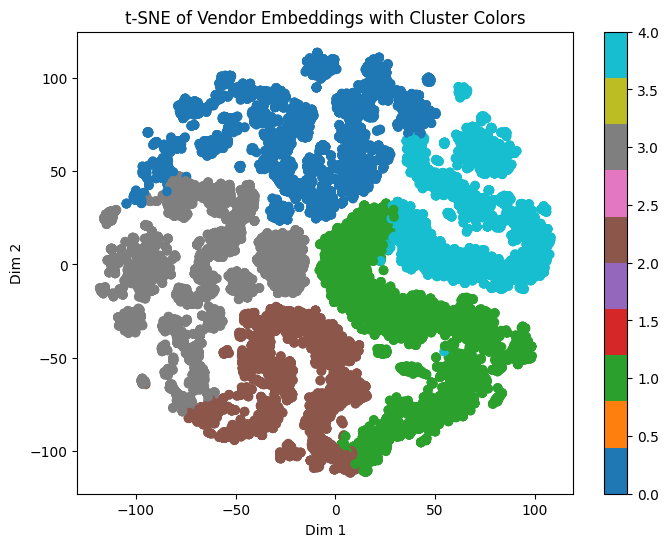

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load embeddings
left_embeddings_df = pd.read_csv("abs_and_cosine_classification_layer/left_vendor_embeddings.csv")
right_embeddings_df = pd.read_csv("abs_and_cosine_classification_layer/right_vendor_embeddings.csv")
embeddings_df = pd.concat([left_embeddings_df,right_embeddings_df])
embeddings = embeddings_df.values

# Run embedding clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_emb = kmeans.fit_predict(embeddings)

# Visualize
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels_emb, cmap='tab10')
plt.title("t-SNE of Vendor Embeddings with Cluster Colors")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(scatter)
plt.show()

In [60]:
left_cluster_labels = cluster_labels_emb[0:10000].tolist()
right_cluster_labels = cluster_labels_emb[10000:20000].tolist()

In [61]:
training_data_py_ar["left_embedding_cluster_label"]=left_cluster_labels
training_data_py_ar["right_embedding_cluster_label"]=right_cluster_labels

In [ ]:
training_data_py_ar[training_data_py_ar["left_embedding_cluster_label"]==3][["left_name","left_address","left_keywords","left_lat", "left_lng"]].sample(n=20)

In [73]:
training_data_py_ar[training_data_py_ar["right_embedding_cluster_label"]==4][["right_name","right_address","right_keywords","right_lat", "right_lng"]].sample(n=20)

,right_name,right_address,right_keywords,right_lat,right_lng
9752,storybrooke lanus,gdor carlos tejedor 225 b1824 lanus argentina,con smoothie expresso waffle licuado frutos ro...,-34.702336,-58.394926
4847,mostaza ramos mejia,belgrano 86,combo doble papas regulares xl mega bacon cuar...,-34.642049,-58.565140
7079,la causa nikkei downtown ii,25 de mayo 574,roll causita 25 salmon nikkei 12 and nigiri sa...,-34.601115,-58.371334
948,club del poke - liniers,cnel ramon l falcon 7145,sushi salad poke crispy tu pollo bowl veggie d...,-34.639988,-58.527055
7149,asu mare! barra cevichera,av pueyrredon 535,ml ceviche 354 chicharrón gaseosa mariscos que...,-34.604154,-58.405293
6215,miwa - escobar,av eugenia tapia de cruz 843 local 15,piezas cc salad cerveza tabla sushi gascón con...,-34.348327,-58.796424
4547,imperio da coxinha abasto,lavalle 2922 entre calles ecuador y jean jaure...,unidades combo feira pastel queso vegano mini ...,-34.603060,-58.407797
747,betos devoto,jose pedro varela 4866,betos papas con burger lomo promo huevo median...,-34.611935,-58.517634
6021,vipentto calle 45,calle 45 n deg 650 esquina 9 b1900 la plata pr...,helado unidad promo potes cucurucho,-34.913424,-57.956171
3423,valence - adrogue,segui 671 local 1,cc münsta helado ddl 240 postre off chocolate ...,-34.800273,-58.397053


In [43]:
from sklearn.metrics import silhouette_score

score = silhouette_score(embeddings, cluster_labels_emb)

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.5532


In [45]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sims = cosine_similarity(embeddings)
vendor_idx = 0  # change this
similar_idxs = np.argsort(-sims[vendor_idx])[1:6]  # skip self

print(f"Top 5 neighbors for vendor {vendor_idx}: {similar_idxs}")

Top 5 neighbors for vendor 0: [ 9587  9453  7463 19453 17510]


In [54]:
training_data_py_ar[["left_name","left_address","left_keywords","left_lat", "left_lng"]][0:1]

,left_name,left_address,left_keywords,left_lat,left_lng
0,la payada - callao,avenida callao 1391 buenos aires argentina,pizza empanada muzzarella jamón con calabresa ...,-34.5928,-58.3928


In [55]:
training_data_py_ar[["left_name","left_address","left_keywords","left_lat", "left_lng"]][9587:9588]

,left_name,left_address,left_keywords,left_lat,left_lng
9587,la payada - callao,avenida callao 1391 buenos aires argentina,pizza empanada muzzarella jamón con calabresa ...,-34.5928,-58.3928


In [56]:
training_data_py_ar[["left_name","left_address","left_keywords","left_lat", "left_lng"]][9453:9454]

,left_name,left_address,left_keywords,left_lat,left_lng
9453,la payada - av la plata,av la plata 777 c1235 abe buenos aires argentina,empanada pizza muzzarella jamón con 500 ml car...,-34.6246,-58.4274


In [58]:
training_data_py_ar[["left_name","left_address","left_keywords","left_lat", "left_lng"]][7463:7464]

,left_name,left_address,left_keywords,left_lat,left_lng
7463,la payada - av la plata,av la plata 777 c1235 abe buenos aires argentina,empanada pizza muzzarella jamón con 500 ml car...,-34.6246,-58.4274


In [57]:
training_data_py_ar[["right_name","right_address","right_keywords","right_lat", "right_lng"]][9453:9454]

,right_name,right_address,right_keywords,right_lat,right_lng
9453,la payada - av la plata,av la plata 777,empanada pizza grande muzzarella con ml jamón ...,-34.624617,-58.427195


In [59]:
training_data_py_ar[["right_name","right_address","right_keywords","right_lat", "right_lng"]][7510:7511]

,right_name,right_address,right_keywords,right_lat,right_lng
7510,la payada - belgrano,avenida monroe 2912,empanada pizza grande muzzarella con ml jamón ...,-34.561152,-58.464831


In [74]:
training_data_py_ar[0:1]

,left_lead_id,left_name,left_name_local,left_address,left_lat,left_lng,left_menu,right_lead_id,right_name,right_name_local,...,right_lat,right_lng,right_menu,predicted_label,prob,left_keywords,right_keywords,haversine,left_embedding_cluster_label,right_embedding_cluster_label
0,3081f302-8d76-438f-aab8-9cf83a3ec2d9,la payada - callao,la payada - callao,avenida callao 1391 buenos aires argentina,-34.5928,-58.3928,empanada capresse ta empanada de carne porteñ...,HWJQCY,la payada - recoleta,la payada - recoleta,...,-34.59284,-58.392858,levite manzana 500 ml pizza grande calabresa e...,1,0.998209,pizza empanada muzzarella jamón con calabresa ...,empanada pizza grande muzzarella con ml jamón ...,0.00693,4,4


In [76]:
sims[0,10000]

np.float64(0.9994999971344708)

## 3. Multi-country model (AR + PE)

### 3.1 Generate PE and PE+A training data

In [23]:
query = """
select * from `dh-global-sales-data-dev.leadgen_temp.exp_training_data_match_PY_PE`
"""

df_training_data_match_py_pe = pd.read_gbq(query=query, project_id = project_id, progress_bar_type = 'tqdm')

/var/tmp/ipykernel_4262/1928696351.py:5: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_training_data_match_py_pe = pd.read_gbq(query=query, project_id = project_id, progress_bar_type = 'tqdm')


Downloading: 100%|██████████|


In [24]:
query = """
select * from `dh-global-sales-data-dev.leadgen_temp.exp_training_data_no_match_PY_PE`
"""

df_training_data_no_match_py_pe = pd.read_gbq(query=query, project_id = project_id, progress_bar_type = 'tqdm')

/var/tmp/ipykernel_4262/1100111763.py:5: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_training_data_no_match_py_pe = pd.read_gbq(query=query, project_id = project_id, progress_bar_type = 'tqdm')


Downloading: 100%|██████████|


In [25]:
df_training_data_match_py_pe.head()

,left_lead_id,left_name,left_name_local,left_street,left_lat,left_lng,left_phone_number,left_menu,right_lead_id,right_name,right_name_local,right_street,right_lat,right_lng,right_phone_number,right_menu,predicted_label,prob
0,cc965e5f-8e15-4a12-8797-7cb63e489650,tequecheese minka centro comercial minka,tequecheese minka centro comercial minka,centro comercial minka av argentina 3093 calla...,-12.0480,-77.1125,None,"[box party, kids de tequeños de queso, persona...",HAJJF2,tequecheese - minka,tequecheese - minka,centro comercial minka modulo se encuentra en ...,-12.048093,-77.112300,+51982072188,"[personal de pastelitos de pizza x 3 und, ¡hoy...",1,0.964700
1,7867dc97-c253-47e3-9682-38aa8099aa83,kfc 154 mega express villa chorrillos,kfc 154 mega express villa chorrillos,alameda sur 600 chorrillos cruce con alameda s...,-12.1963,-77.0110,None,"[pop corn para 2, chickn share verano, ensalad...",HWRD2G,kfc - mega express villa,kfc - mega express villa,av alameda sur,-12.197219,-77.011049,+51914449405,"[off mega promo 10 piezas, off mega familia...",1,0.957796
2,e69fd945-a467-4edf-b171-90bc5dcfa3e4,starbucks 89 - real plaza arequipa,starbucks 89 - real plaza arequipa,ejercito 1009 cc real plaza arequipa,-16.3892,-71.5494,None,"[wb mexico puebla 250g, café frappuccino, sánd...",HWGC1G,starbucks - real plaza arequipa,starbucks - real plaza arequipa,av ejercito,-16.389797,-71.550034,+51914449405,"[pink drink refresher, mocha blanco shaken esp...",1,0.961686
3,ed3d6067-4890-4997-8b80-aa084ce7289c,crem dela crem - punta hermosa,crem dela crem - punta hermosa,calle islas ballestas 734 esquina de la av sun...,-12.3323,-76.8274,None,"[sorbetto de fresa mediano, gelato de blueberr...",4F35QT,crem dela crem - sunset,crem dela crem - sunset,av sunset cuadra,-12.332214,-76.827399,51991647757,"[gelato de lucuma, keke de manzana y arándanos...",1,0.954156
4,3cccc065-2fab-4d4d-a407-43b87d1be3c1,asnapa,asnapa,asnapa restaurante calle alcanfores miraflores...,-12.1221,-77.0277,None,"[arroz con chancho, ceviche de temporada, salt...",4FG6B6,asnapa cocina peruana,asnapa cocina peruana,calle alcanfores,-12.122124,-77.027670,+51980165161,"[pato al aji con yuca y arrroz, sancochado de ...",1,0.957189


In [26]:
len(df_training_data_match_py_pe)

2535

In [28]:
df_training_data_no_match_py_pe.head()

,left_lead_id,left_name,left_name_local,left_street,left_lat,left_lng,left_phone_number,left_menu,right_lead_id,right_name,right_name_local,right_street,right_lat,right_lng,right_phone_number,right_menu,predicted_label,prob
0,51f74952-89a7-4207-9c6b-ea1fa8a2be10,cevicheria pescadorita,cevicheria pescadorita,avenida arenales 993,-12.0746,-77.0370,None,"[chaufa de pescado, triple pesca, leche de tig...",HWY723,sabores en victoria,sabores en victoria,prolongacion la mar,-12.064910,-77.019529,+51986720806,"[combo brasa 3, tallarines salteados criollo, ...",0,0.059834
1,2a11a2c2-d67c-4cc7-8f3a-24a171cafadf,issei -surquillo,issei -surquillo,san diego 651 surquillo peru,-12.1186,-77.0199,None,"[inca kola sabor original 500 ml, makis jalea,...",4F3ONN,hibashi,hibashi,cc balboa strip mall av vasco nunez de balboa ...,-12.129550,-77.024266,51982570523,"[tako miso, parrillero, nigiris de salmón, tig...",0,0.053884
2,9dbfc068-d13f-421a-9fa9-a9ce65786d68,burger box,burger box,jr domingo casanova 531,-12.0892,-77.0303,None,"[combo clásica 200 gr, papas fritas, inca cola...",HAPOT0,bao house,bao house,jiron francisco de zela,-12.082652,-77.039965,+51945227783,"[agua san luis sin gas 750ml, sweet bulgogi ba...",0,0.056807
3,20968476-e37a-4a20-a647-f5abbad1d85f,san buche lima,san buche lima,av caminos del inca 3193 santiago de surco 150...,-12.1431,-76.9849,None,"[sánguche de chanchito a la caja china, inca k...",HWX2K2,kfc - los heroes,kfc - los heroes,av los heroes 240 - cruce con antonio buckingham,-12.152399,-76.976597,+51914449405,"[mega full 12 piezas, combo chickn share 4 pi...",0,0.057767
4,0f3a31ac-47be-470c-a08a-05519dc4ff34,chifa el sol,chifa el sol,av simon bolivar 1179 pueblo libre 15084 peru,-12.0726,-77.0661,None,"[combo 15, pollo en trozos con tamarindo, lang...",HW86CC,cineplanet brasil,cineplanet brasil,av brasil,-12.066109,-77.047245,+51987946348,"[combo mix hot dog odd, calendario cp 2025,...",0,0.058153


In [27]:
len(df_training_data_no_match_py_pe)

15754

In [31]:
sample_match_py_pe = df_training_data_match_py_pe.sample(n=2500, random_state=1)

In [32]:
sample_no_match_py_pe = df_training_data_no_match_py_pe.sample(n=2500, random_state=1)

In [38]:
training_data_py_pe = pd.concat([sample_match_py_pe,sample_no_match_py_pe], ignore_index=True)

In [39]:
training_data_py_pe[(training_data_py_pe["left_phone_number"].isna()==False)&(training_data_py_pe["right_phone_number"].isna()==False)]

,left_lead_id,left_name,left_name_local,left_street,left_lat,left_lng,left_phone_number,left_menu,right_lead_id,right_name,right_name_local,right_street,right_lat,right_lng,right_phone_number,right_menu,predicted_label,prob


In [40]:
training_data_py_pe = training_data_py_pe.drop(columns=["left_phone_number", "right_phone_number"])

In [41]:
training_data_py_pe = training_data_py_pe.sample(frac=1).reset_index(drop=True)

In [42]:
def concatenate_menu(text_array):
    return " ".join(text_array)

training_data_py_pe["left_menu"] = training_data_py_pe.apply(lambda x: concatenate_menu(x.left_menu), axis=1)
training_data_py_pe["right_menu"] = training_data_py_pe.apply(lambda x: concatenate_menu(x.right_menu), axis=1)

In [43]:
spanish_stopwords_menu = [
    "a", "al", "algo", "alguna", "algunas", "alguno", "algunos", "ante", "antes", "bajo", "cual", "cuales", 
    "cualquier", "cuando", "de", "debe", "del", "demás", "demasiado", "desde", "donde", "dos", "durante", "e", 
    "el", "ella", "ellas", "ellos", "en", "encima", "entonces", "entre", "esta", "estas", "este", "esto", "estos", 
    "la", "las", "lo", "los", "me", "mi", "mis", "muchos", "muy", "nada", "ni", "ningún", "ninguna", "ninguno", "no", 
    "nos", "nosotros", "nuestra", "nuestro", "os", "para", "pero", "por", "porque", "que", "quien", "quienes", "se", 
    "si", "sí", "sólo", "son", "su", "sus", "suya", "suyo", "tal", "tales", "también", "te", "tendrá", "tengo", "tiempo", 
    "toda", "todas", "todo", "todos", "tras", "un", "una", "unas", "uno", "unos", "usted", "y", "ya", "yo", "kg", "pz", "pieza"
]

def extract_top_keywords(text, top_n=50):
    """
    Given a text string, clean it and then fit a TF-IDF vectorizer on it (as a single document)
    to extract the top_n keywords. Returns the keywords as a single space‐joined string.
    If the cleaned text is empty, returns a single space " ".
    """
    # if not isinstance(text, str) or not text.strip():
    #     return " "
    
    # # Clean the text.
    # cleaned_text = clean_text(text)
    # if not cleaned_text.strip():
    #     return " "
    cleaned_text = text
    
    # Pass the stopwords to the vectorizer as well.
    vectorizer = TfidfVectorizer(stop_words=spanish_stopwords_menu)
    tfidf_matrix = vectorizer.fit_transform([cleaned_text])
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = tfidf_matrix.toarray()[0]
    
    # Get indices of the top_n scores in descending order.
    sorted_indices = np.argsort(tfidf_scores)[::-1]
    top_keywords = [feature_names[i] for i in sorted_indices[:top_n]]
    return " ".join(top_keywords)

In [44]:
training_data_py_pe["left_keywords"] = training_data_py_pe.apply(lambda x: extract_top_keywords(x.left_menu), axis=1)
training_data_py_pe["right_keywords"] = training_data_py_pe.apply(lambda x: extract_top_keywords(x.right_menu), axis=1)

In [45]:
training_data_py_pe = training_data_py_pe.rename(columns={"left_street":"left_address", "right_street":"right_address"})

In [46]:
training_data_py_pe.head()

,left_lead_id,left_name,left_name_local,left_address,left_lat,left_lng,left_menu,right_lead_id,right_name,right_name_local,right_address,right_lat,right_lng,right_menu,predicted_label,prob,left_keywords,right_keywords
0,1d27b7d6-2f3f-472d-97fc-efb266d4bda3,sanguchon campesino san luis,sanguchon campesino san luis,av del aire 1218 san luis peru,-12.0783,-76.9986,sándwich pavo especial sándwich chorizo hawaia...,4CS07V,sanguchon campesino - san luis,sanguchon campesino - san luis,avenida del aire,-12.078320,-76.998557,mixto lechon tacos pavo enchilada de pollo b...,1,0.966388,sándwich enchilada taco especial mixto simple ...,sanguchón enchilada mixto pollo tacos con espe...
1,275991e3-f69c-4bcf-a8cb-c5559048bcff,la pizzota delivery,la pizzota delivery,jiron victor sarria 1354 cercado de lima 15081...,-12.0539,-77.0708,pizza parrillera pizza americana combo mediano...,HZTA2Z,la pizzota delivery - lima,la pizzota delivery - lima,jiron victor sarria,-12.053880,-77.070842,pizza suprema promo la fija mediana la mita a...,1,0.966388,pizza combo and peperoni supremafest familiar ...,pizza promo gaseosa ml combo hawaiana peperoni...
2,f08df582-0469-4577-a581-2ba05a6e8f1f,buen caldo la victoria,buen caldo la victoria,av pablo patron 421 la victoria 15019 peru 2do...,-12.0686,-76.9997,inca kola sabor original 600 ml naturale chich...,HA80OW,el buen caldo la victoria,el buen caldo la victoria,av pablo patron,-12.068561,-76.999718,inca kola chaufa de gallina cocacola caldo ace...,1,0.966552,saltado ml original pollo 600 sabor caldo chau...,saltado gallina chaufa pollo caldo tallarin yu...
3,7ab7a955-c016-41dd-8c89-acea886d858b,chinawok lima plaza sur,chinawok lima plaza sur,av paseo de la republica chorrillos 15064 peru,-12.1720,-77.0133,duo clásico al wok dúo encájate al wok promo e...,4F3T5Y,chinawok plaza lima sur,chinawok plaza lima sur,paseo de la republica chorrillos 15064 peru,-12.171983,-77.013378,promo honey al wok pollo chi jau kay 37off pr...,1,0.956916,promo duo pro banquete wok pollo familiar enca...,promo duo banquete pollo wok sabor encájate ja...
4,eda521c8-fe9c-4c32-a5d0-ca25bc89f74c,hibashi japanese food,hibashi japanese food,av vasco nunez de balboa 751 miraflores,-12.1295,-77.0243,arroz frito con langostinos media tabla de kan...,HA8ZCV,polleria -brasitas express,polleria -brasitas express,jiron combate de angamos,-12.142775,-77.007674,mega combo brasitas salchimostrazo costillitas...,0,0.056268,nigiri medio sashimi tabla media langostinos m...,pollo brasa papas brasitas pepsi parrilla prom...


In [47]:
import math

def compute_haversine(lat1, lon1, lat2, lon2) -> float:
    """
    Returns haversine distance in *km*
    """
    # Convert coordinates from degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    )
    c = 2 * math.asin(math.sqrt(a))

    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

In [48]:
training_data_py_pe["haversine"] = training_data_py_pe.apply(lambda x: compute_haversine(x.left_lat, x.left_lng, x.right_lat, x.right_lng), axis=1)

In [50]:
training_data_py_pe.to_gbq("dh-global-sales-data-dev.leadgen_temp.exp_training_data_PY_PE")

/var/tmp/ipykernel_4262/2640569762.py:1: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  training_data_py_pe.to_gbq("dh-global-sales-data-dev.leadgen_temp.exp_training_data_PY_PE")
100%|██████████| 1/1 [00:00<00:00, 10512.04it/s]


In [74]:
training_data_py_ar['country_iso'] = 'AR'
training_data_py_pe['country_iso'] = 'PE'

In [75]:
training_data_py_ar_pe = pd.concat([training_data_py_ar.sample(n=5000, random_state=1), training_data_py_pe])

In [76]:
training_data_py_ar_pe = training_data_py_ar_pe.sample(frac=1).reset_index(drop=True)

In [80]:
training_data_py_ar_pe[0:10]

,left_lead_id,left_name,left_name_local,left_address,left_lat,left_lng,left_menu,right_lead_id,right_name,right_name_local,right_address,right_lat,right_lng,right_menu,predicted_label,prob,left_keywords,right_keywords,haversine,country_iso
0,3fba976d-16fb-43e4-a41b-956148f6c374,bembos helados - repsol la molina,bembos helados - repsol la molina,av la molina 2880 la molina peru,-12.083400,-76.927900,sprite sabor original 500 ml coca cola sabor o...,HRNSO6,la salteneria - la molina,la salteneria - la molina,santiago de compostela 157,-12.087166,-76.935432,pastel de yuca grande salteñas de carne median...,0,0.057877,500 ml original sabor azúcar sin cola coca kol...,pastel carne yuca salteña salteñas empanada ej...,0.919817,PE
1,e40dfe0f-648c-4bc3-9814-4ffc054fd109,la helateria,la helateria,av mariano h cornejo 1351 pueblo libre 15084 peru,-12.067500,-77.064200,milkshake de casino de menta copa oreo mega cl...,HWFFLJ,jiron shungo anticuchos,jiron shungo anticuchos,jiron huiracocha,-12.080410,-77.050860,gaseosa inca kola sin azúcar 600ml salchicucho...,0,0.053251,con helado fresas crepe waffle jugo pollo ml 6...,porción rachi choncholi molleja gaseosa 600ml ...,2.040744,PE
2,7b3f69bf-44ff-40a3-876f-4868ef81b856,bobby sabe,bobby sabe,calle sucre 202 arequipa peru,-16.399300,-71.538900,"combo chapito, papas y bebida combo cheesy bob...",HAMJB7,bobby sabe,bobby sabe,calle sucre 202 arequipa,-16.399351,-71.538889,salsa bbq agua andea ketchup bobby bbq blaze l...,1,0.966388,papas bebida combo ml 500 bobby bbq sueldo sin...,ml 500 500ml zero inca hamburguesa bobby cocac...,0.005803,PE
3,70ceebcb-b6d3-41db-be92-6dff43153b91,mama chabe,mama chabe,c teniente cesar lopez rojas 240 lima 15088 peru,-12.075000,-77.089700,tallarines verdes con milanesa de pollo hambur...,HZQAQJ,chifa tomy,chifa tomy,avenida universitaria,-12.066540,-77.077714,"combinado de pollo tipakay, chicharrón de poll...",0,0.057375,con ml chicharrón jugo pollo broaster parrilla...,con pollo chaufa chijaukay tipakay plato chich...,1.607302,PE
4,70e66046-f912-4e2b-8251-6662b3f52f45,cukeez surco,cukeez surco,el polo 695 santiago de surco,-12.101300,-76.972100,café cukeez tostado oscuro chocochips san lui...,4F3NKR,mamma tomato pizza - surco,mamma tomato pizza - surco,av javier prado este,-12.081964,-76.967599,limonada clásica 335ml tutto carne grande la t...,0,0.057688,infusión cukeez and ml blondie original olla m...,grande mediana americana hawaiiana gran carne ...,2.205078,PE
5,17769cd3-36c4-4503-9472-88dc95389488,el pela,el pela,alemania 2454 n3300hwc posadas misiones argentina,-27.395700,-55.904600,milanesa de carne napo con papas coca cola por...,HA3BFM,el pela rotiseria,el pela rotiseria,alemania 2454 n3300 posadas argentina,-27.395740,-55.904606,imperial golden 473 poste bombón suizo milanes...,1,0.998679,papas pizza milanesa hamburguesas con fritas c...,con papas completa mozzarella hamburguesas mil...,0.004483,AR
6,1f1d2b25-163f-4c20-89f0-402d310a92e8,brutal salchipapas,brutal salchipapas,av manuel villaran 1114 surquillo 15038 peru,-12.120400,-76.999500,salchibacon salchipapa royal pollipapa salchip...,4CPAHB,brutal salchipapas - lima,brutal salchipapas - lima,av manuel villaran 1114,-12.120353,-76.999485,choripapa papas fritas refresco cocacola zero ...,1,0.966388,salchipapa zero inca coca kola cola sprite pob...,salchipapa ml 600 jugo gaseosa mateo original ...,0.005501,PE
7,c6209ebb-4991-45fb-b511-f761db1d21f6,roma salteneria - colon,roma salteneria - colon,c colon 135 arequipa 04001 peru,-16.399100,-71.531500,porción de pastel de acelga combo para 2 combo...,HARWQ2,los gomez polleria,los gomez polleria,maria nieves y bustamante 104 umacollo arequipa,-16.404123,-71.546790,inca kola personal promo 1/4 pollo a la brasa...,0,0.056268,res sabor 600 carne combo kola ml original por...,pollo brasa promo grande combo salchipapa supe...,1.723964,PE
8,1e8dc1a0-2229-4582-a28e-632a03d28a1a,postres mcdonalds - hy3,postres mcdonalds - hy3,av hipolito yrigoyen,-34.743215,-58.

In [79]:
training_data_py_ar_pe.to_gbq("dh-global-sales-data-dev.leadgen_temp.exp_training_data_PY_AR_PE")

/var/tmp/ipykernel_4262/3782386174.py:1: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  training_data_py_ar_pe.to_gbq("dh-global-sales-data-dev.leadgen_temp.exp_training_data_PY_AR_PE")
100%|██████████| 1/1 [00:00<00:00, 11125.47it/s]


### 3.2 Architecture and model training

In [82]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import pandas as pd

class DualTowerBiEncoder(nn.Module):
    def __init__(self, model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", reduced_dim=256, tfidf_dim=100):
        super(DualTowerBiEncoder, self).__init__()
        self.semantic_encoder = SentenceTransformer(model_name)
        self.transformer = self.semantic_encoder._first_module().auto_model
        self.tokenizer = self.semantic_encoder.tokenizer

        # Unfreeze transformer parameters for fine-tuning
        for param in self.transformer.parameters():
            param.requires_grad = True

        hidden_size = self.transformer.config.hidden_size

        self.semantic_projection = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        self.lexical_projection = nn.Sequential(
            nn.Linear(tfidf_dim, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        self.final_projection = nn.Sequential(
            nn.Linear(2 * reduced_dim, 256),
            nn.ReLU(),
            nn.Linear(256, reduced_dim)
        )

        # Classification head (input includes haversine distance)
        self.classifier = nn.Sequential(
            nn.Linear(reduced_dim + 2, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def encode_semantic(self, name_and_keywords):
        inputs = self.tokenizer(name_and_keywords, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {key: value.to(next(self.semantic_projection.parameters()).device) for key, value in inputs.items()}
        outputs = self.transformer(**inputs)
        text_embedding = outputs.last_hidden_state[:, 0, :]
        return self.semantic_projection(text_embedding)

    def encode_lexical(self, tfidf_vector):
        return self.lexical_projection(tfidf_vector)

    def forward(self, left_text, right_text, left_tfidf, right_tfidf, haversine_dists):
        left_semantic_embed = self.encode_semantic(left_text)
        right_semantic_embed = self.encode_semantic(right_text)

        left_lexical_embed = self.encode_lexical(left_tfidf)
        right_lexical_embed = self.encode_lexical(right_tfidf)

        left_final_embed = self.final_projection(torch.cat((left_semantic_embed, left_lexical_embed), dim=1))
        right_final_embed = self.final_projection(torch.cat((right_semantic_embed, right_lexical_embed), dim=1))

        # Normalize embeddings
        left_final_embed = F.normalize(left_final_embed, p=2, dim=1)
        right_final_embed = F.normalize(right_final_embed, p=2, dim=1)

        # Classification prediction
        abs_diff = torch.abs(left_final_embed - right_final_embed)
        cosine_sim = F.cosine_similarity(left_final_embed, right_final_embed).unsqueeze(1)
        combined = torch.cat((abs_diff, cosine_sim, haversine_dists.unsqueeze(1)), dim=1)
        match_prob = self.classifier(combined)

        return left_final_embed, right_final_embed, match_prob

In [84]:
# Dataset class
class VendorMatchingDataset(Dataset):
    def __init__(self, left_names, right_names, left_addresses, right_addresses, left_keywords, right_keywords, haversine_distances, labels):
        self.left_names = left_names
        self.right_names = right_names
        self.left_keywords = left_keywords
        self.right_keywords = right_keywords
        self.left_addresses = left_addresses
        self.right_addresses = right_addresses
        self.haversine_distances = haversine_distances
        self.labels = labels

        self.left_lexical_inputs = [f"{n} {a}" for n, a in zip(left_names, left_addresses)]
        self.right_lexical_inputs = [f"{n} {a}" for n, a in zip(right_names, right_addresses)]
        self.left_semantic_inputs = [f"{n} {' '.join(k)}" for n, k in zip(left_names, left_keywords)]
        self.right_semantic_inputs = [f"{n} {' '.join(k)}" for n, k in zip(right_names, right_keywords)]

        vectorizer = TfidfVectorizer(max_features=100)
        vectorizer.fit(self.left_lexical_inputs + self.right_lexical_inputs)
        self.vectorizer = vectorizer

        self.left_tfidf_vectors = [self.vectorizer.transform([txt]).toarray()[0] for txt in self.left_lexical_inputs]
        self.right_tfidf_vectors = [self.vectorizer.transform([txt]).toarray()[0] for txt in self.right_lexical_inputs]
        self.tfidf_dim = self.left_tfidf_vectors[0].shape[0]

    def __getitem__(self, idx):
        return (
            self.left_semantic_inputs[idx],
            self.right_semantic_inputs[idx],
            torch.tensor(self.left_tfidf_vectors[idx], dtype=torch.float32),
            torch.tensor(self.right_tfidf_vectors[idx], dtype=torch.float32),
            torch.tensor(np.log1p(self.haversine_distances[idx]) / np.log1p(100), dtype=torch.float32),
            self.labels[idx]
        )

    def __len__(self):
        return len(self.labels)

# Training function

import time
import gc

def train_with_split(model, dataset, train_ratio=0.8, epochs=10, batch_size=32, lr=1e-5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    total_size = len(dataset)
    train_size = int(train_ratio * total_size)
    test_size = total_size - train_size
    indices = list(range(total_size))
    np.random.shuffle(indices)

    train_indices = indices[:train_size]
    test_indices = indices[train_size:]

    pd.Series(train_indices).to_csv("train_indices.csv", index=False)
    pd.Series(test_indices).to_csv("test_indices.csv", index=False)

    train_set = torch.utils.data.Subset(dataset, train_indices)
    test_set = torch.utils.data.Subset(dataset, test_indices)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, num_workers=2, pin_memory=True)

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    loss_fn = nn.BCELoss()

    print(f"Training on: {device}")
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        val_loss = 0
        model.train()
        total_loss = 0

        for batch in train_loader:
            left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists, labels = batch
            left_tfidf = left_tfidf.to(device)
            right_tfidf = right_tfidf.to(device)
            haversine_dists = haversine_dists.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            _, _, match_probs = model(left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists)
            loss = loss_fn(match_probs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        model.eval()
        with torch.no_grad():
            for batch in test_loader:
                left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists, labels = batch
                left_tfidf = left_tfidf.to(device)
                right_tfidf = right_tfidf.to(device)
                haversine_dists = haversine_dists.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                _, _, match_probs = model(left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists)
                val_loss += loss_fn(match_probs, labels).item()

        avg_val_loss = val_loss / len(test_loader)
        preds = match_probs.cpu().numpy()
        true = labels.cpu().numpy()
        binary_preds = (preds >= 0.5).astype(int)

        f1 = f1_score(true, binary_preds)
        precision = precision_score(true, binary_preds)
        recall = recall_score(true, binary_preds)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f} - Val Loss: {avg_val_loss:.4f} - F1: {f1:.4f} - Precision: {precision:.4f} - Recall: {recall:.4f}")

    torch.save(model.state_dict(), "trained_model.pt")

    def save_predictions(loader, subset_name):
        model.eval()
        predictions = []
        with torch.no_grad():
            for batch in loader:
                left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists, labels = batch
                left_tfidf = left_tfidf.to(device)
                right_tfidf = right_tfidf.to(device)
                haversine_dists = haversine_dists.to(device)
                labels = labels.float().to(device)
                _, _, match_probs = model(left_texts, right_texts, left_tfidf, right_tfidf, haversine_dists)
                for l, p in zip(labels.cpu().numpy(), match_probs.cpu().numpy()):
                    predictions.append((float(l), float(p)))
        df = pd.DataFrame(predictions, columns=["label", "predicted_probability"])
        df.to_csv(f"{subset_name}_predictions.csv", index=False)

    save_predictions(train_loader, "train")
    save_predictions(test_loader, "test")

    end_time = time.time()
    print(f"Total training time: {(end_time - start_time)/60:.2f} minutes")
    gc.collect()
    torch.cuda.empty_cache()

    return model

In [85]:
model = DualTowerBiEncoder()

In [86]:
training_dataset = training_data_py_ar_pe

In [87]:
# Prepare inputs for dataset
left_names = training_dataset["left_name"].tolist()
right_names = training_dataset["right_name"].tolist()
left_addresses = training_dataset["left_address"].tolist()
right_addresses = training_dataset["right_address"].tolist()
left_keywords = training_dataset["left_keywords"].tolist()
right_keywords = training_dataset["right_keywords"].tolist()
haversines = training_dataset["haversine"].tolist()
labels = training_dataset["predicted_label"].tolist()

# Create dataset
dataset = VendorMatchingDataset(
    left_names, right_names,
    left_addresses, right_addresses,
    left_keywords, right_keywords,
    haversines,
    labels
)

In [88]:
trained_model_ar_pe_with_cosine = train_with_split(model, dataset)

Training on: cuda


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch 1/10 - Train Loss: 0.6830 - Val Loss: 0.6675 - F1: 0.8333 - Precision: 0.8333 - Recall: 0.8333


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 2/10 - Train Loss: 0.6567 - Val Loss: 0.6541 - F1: 0.5556 - Precision: 0.4167 - Recall: 0.8333


...

Epoch 9/10 - Train Loss: 0.4825 - Val Loss: 0.5011 - F1: 0.9091 - Precision: 1.0000 - Recall: 0.8333


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 10/10 - Train Loss: 0.4648 - Val Loss: 0.4855 - F1: 0.9091 - Precision: 1.0000 - Recall: 0.8333


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/var/tmp/ipykernel_4262/274753656.py:132: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions.append((float(l), float(p)))
huggingface/tokenizers: The current process ju

Total training time: 20.69 minutes


In [95]:
extract_vendor_embeddings(trained_model_ar_pe_with_cosine, dataset)

Saved 10000 left and right vendor embeddings to left_vendor_embeddings.csv and right_vendor_embeddings.csv


## 3.3 Evaluation

#### Classification metrics

In [90]:
train_predictions_path = 'train_predictions.csv'
test_predictions_path = 'test_predictions.csv'

In [91]:
evaluate_predictions_from_csv(train_predictions_path)

📊 Evaluation from: train_predictions.csv
  Precision: 0.9370
  Recall:    0.9521
  F1 Score:  0.9445
  ROC AUC:   0.9819


{'precision': 0.9370059288537549,
 'recall': 0.9520582329317269,
 'f1': 0.9444721115537849,
 'roc_auc': np.float64(0.9819107418218691)}

In [92]:
evaluate_predictions_from_csv(test_predictions_path)

📊 Evaluation from: test_predictions.csv
  Precision: 0.8787
  Recall:    0.9167
  F1 Score:  0.8973
  ROC AUC:   0.9583


{'precision': 0.8787295476419634,
 'recall': 0.9166666666666666,
 'f1': 0.8972972972972973,
 'roc_auc': np.float64(0.9583323333173331)}